In [2]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from pathlib import Path
from PIL import Image
import imagehash
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## Step 1: Prepare Waste Classification Dataset

### 1.1 Download the Dataset

We will be using the [Recyclable and Household Waste Classification](https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification) on Kaggle. The dataset contains 15,000 images (each 256 x 256 pixels) organized into 30 distinct classes of waste. Each class is further divided into 2 subcategories: `defualt` (studio-like images of waste items) and `real_world` (images of waste items in real-world environments). 

Each class contains 500 images. The images are evenly divided between the two subcategories for each class. 

In [3]:
# Download dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("alistairking/recyclable-and-household-waste-classification")
print(path)


# Declare and initalize global variable DATASET_PATH and SPLITS_PATH
DATASET_PATH = Path("/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification/images/images")
SPLITS_PATH  = Path("/kaggle/working/splits")

/kaggle/input/datasets/alistairking/recyclable-and-household-waste-classification


### 1.2 Set the Random Seed

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1. 3 Map Each Class of Waste to a Disposal Pathway

Each class of waste must be disposed differently. We will map each class of waste within the dataset to one of five disposal pathways: **garbage**, **curbside recycling**, **drop-off recycling** and **compost**. The United States has over 19,000 different municipalities. Each municipality has different recycling rules and guidelines. Therefore, it's impractical to make a disposal mapping for each class of waste that's universally applicable to all municipalities in the nation. Consequently, we will be using the recycling guidelines for the City of Phoenix in this project.

It is important to differentiate between curbside recycling and drop-off recycling. While both options only accept recyclable items, they do differ. For example, while plastic bags are recyclable, they do get disposed of in curbside recycling bins becuase they can damagae machinery at Material Recovery Facilities (MRFs). Instead, they should be disposed of in dropp-off recycling centers where they will be recycled using specialized processes. 


In [5]:
# Lists all classes within dataset
os.listdir(DATASET_PATH)

['plastic_soda_bottles',
 'aerosol_cans',
 'steel_food_cans',
 'disposable_plastic_cutlery',
 'cardboard_boxes',
 'glass_beverage_bottles',
 'plastic_cup_lids',
 'plastic_straws',
 'plastic_shopping_bags',
 'styrofoam_cups',
 'cardboard_packaging',
 'glass_food_jars',
 'styrofoam_food_containers',
 'eggshells',
 'aluminum_food_cans',
 'coffee_grounds',
 'plastic_food_containers',
 'food_waste',
 'magazines',
 'shoes',
 'clothing',
 'aluminum_soda_cans',
 'plastic_detergent_bottles',
 'newspaper',
 'tea_bags',
 'office_paper',
 'plastic_water_bottles',
 'paper_cups',
 'glass_cosmetic_containers',
 'plastic_trash_bags']

In [6]:
# Initializes a dictionary mapping each class of waste within the dataset to a disposal pathway
DISPOSAL_MAP = {

    # Curbside Recycling: 17 classes
    'plastic_soda_bottles':       'curbside_recycling',
    'aerosol_cans':               'curbside_recycling',
    'steel_food_cans':            'curbside_recycling',
    'cardboard_boxes':            'curbside_recycling',
    'glass_beverage_bottles':     'curbside_recycling',
    'plastic_cup_lids':           'curbside_recycling',
    'cardboard_packaging':        'curbside_recycling',
    'glass_food_jars':            'curbside_recycling',
    'aluminum_food_cans':         'curbside_recycling',
    'plastic_food_containers':    'curbside_recycling',
    'magazines':                  'curbside_recycling',
    'aluminum_soda_cans':         'curbside_recycling',
    'plastic_detergent_bottles':  'curbside_recycling',
    'newspaper':                  'curbside_recycling',
    'office_paper':               'curbside_recycling',
    'plastic_water_bottles':      'curbside_recycling',
    'glass_cosmetic_containers':  'curbside_recycling',

    # Drop-off Recycling: 4 classes
    'plastic_shopping_bags':      'dropoff_recycling',
    'plastic_trash_bags':         'dropoff_recycling',
    'clothing':                   'dropoff_recycling',
    'shoes':                      'dropoff_recycling',

    # Compsot: 4 classes
    'eggshells':                  'compost',
    'coffee_grounds':             'compost',
    'tea_bags':                   'compost',
    'food_waste':                 'compost',

    # Garbage: 5 classes
    'disposable_plastic_cutlery': 'garbage',
    'styrofoam_cups':             'garbage',
    'styrofoam_food_containers':  'garbage',
    'plastic_straws':             'garbage',
    'paper_cups':                 'garbage',
}

### 1.4 Display Class Distribution

With the disposal pathway map defined, we can now audit the dataset before splitting it. This cell looks up each class of waste's assigned disposal pathway from `DISPOSAL_MAP`, counts the number of images per class and calculates the percent composition of each class out of the total size of the dataset. It then displays the metrics for each class in a table and writes a csv to the `/kaggle/working`. 

In [7]:
# Appends each class of waste with disposal pathway and number of images into an empty array named records
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    count = sum(1 for f in class_dir.rglob('*') if f.is_file())
    pathway = DISPOSAL_MAP.get(class_name, 'UNMAPPED')
    records.append({'class': class_name, 'count': count, 'pathway': pathway})

df = pd.DataFrame(records).sort_values('count', ascending=False)

# Calculate percent composition of each class out of total dataset size
df['pct'] = (df['count'] / df['count'].sum() * 100).round(2)

# Print table to output and write csv to /kaggle/working
print(df[['class', 'count', 'pct', 'pathway']].to_string(index=False))
df[['class', 'count', 'pct', 'pathway']].to_csv('/kaggle/working/class_distribution_table.csv', index=False)
print("\nSaved to /kaggle/working/class_distribution_table.csv")

                     class  count  pct            pathway
              aerosol_cans    500 3.33 curbside_recycling
        aluminum_food_cans    500 3.33 curbside_recycling
        aluminum_soda_cans    500 3.33 curbside_recycling
           cardboard_boxes    500 3.33 curbside_recycling
       cardboard_packaging    500 3.33 curbside_recycling
                  clothing    500 3.33  dropoff_recycling
            coffee_grounds    500 3.33            compost
disposable_plastic_cutlery    500 3.33            garbage
                 eggshells    500 3.33            compost
                food_waste    500 3.33            compost
    glass_beverage_bottles    500 3.33 curbside_recycling
 glass_cosmetic_containers    500 3.33 curbside_recycling
           glass_food_jars    500 3.33 curbside_recycling
                 magazines    500 3.33 curbside_recycling
                 newspaper    500 3.33 curbside_recycling
              office_paper    500 3.33 curbside_recycling
              

This cell plots the class distribution as a bar chart color coded by disposal pathway.

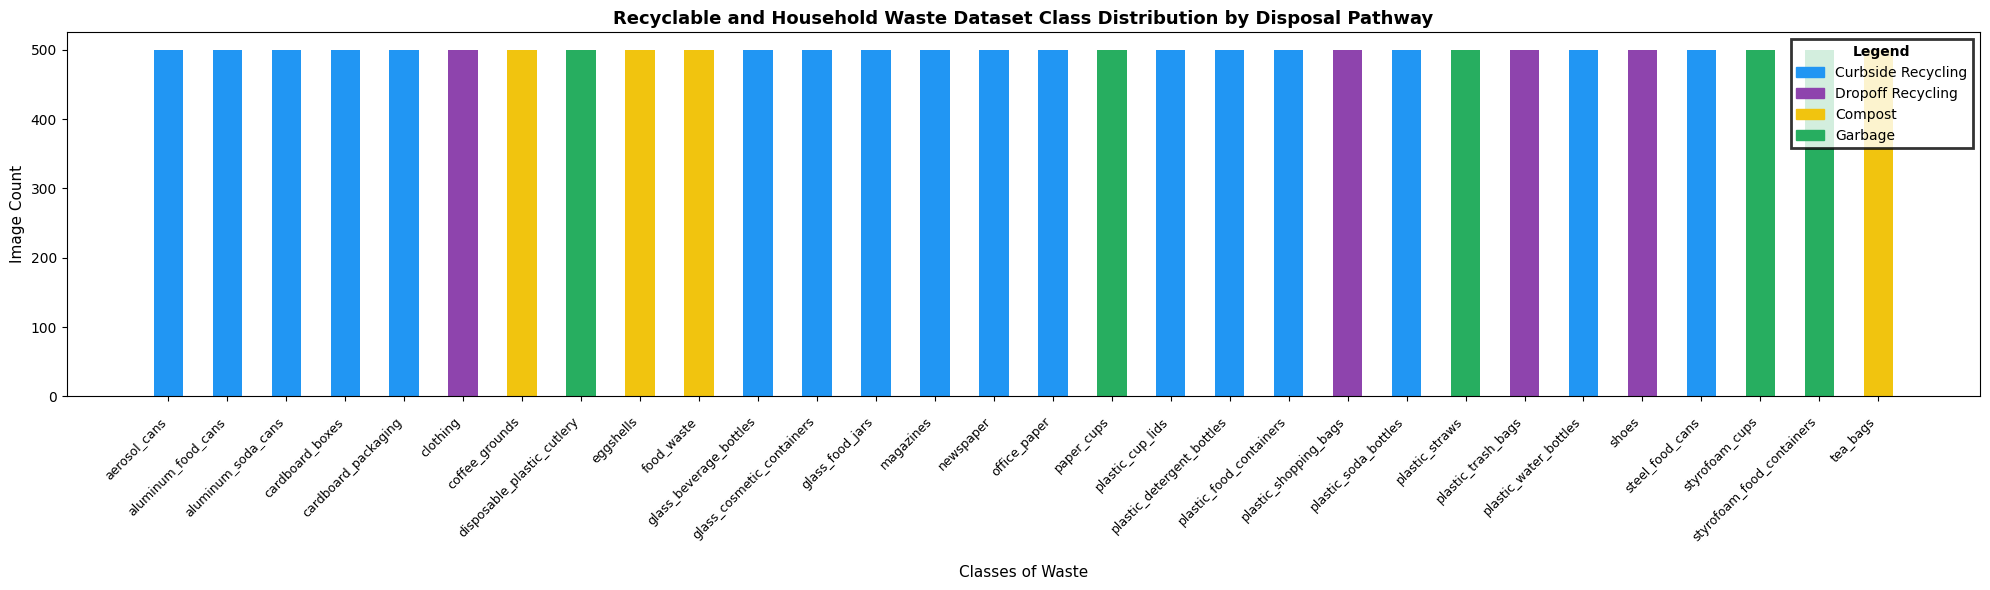

In [13]:
# Initalize dictionary mapping disposal pathways to color for the legend
PATHWAY_COLORS = {
    'curbside_recycling': '#2196F3',
    'dropoff_recycling':  '#8E44AD',
    'compost':            '#F1C40F',
    'garbage':            '#27AE60',
    'UNMAPPED':           '#FF0000',
}

# Display class distribution in bar chart
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(df['class'], df['count'], width=0.5,
       color=[PATHWAY_COLORS.get(p, '#FF0000') for p in df['pathway']])

ax.set_xticks(range(len(df['class'])))
ax.set_xticklabels(df['class'], rotation=45, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=10)

ax.set_xlabel('Classes of Waste', fontsize=11, labelpad=15)
ax.set_ylabel('Image Count', fontsize=11)
ax.set_title('Recyclable and Household Waste Dataset Class Distribution by Disposal Pathway', fontweight='bold', fontsize=13)

legend = ax.legend(
    handles=[mpatches.Patch(color=c, label=p.replace('_', ' ').title())
             for p, c in PATHWAY_COLORS.items() if p in df['pathway'].values],
    loc='upper right',
    title='Legend',
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=True,
    edgecolor='black',
    fancybox=False,
)
legend.get_frame().set_linewidth(2)

# Plot bar chart and save image to /kaggle/working
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_bar_chart.png', dpi=150)
plt.show()

In this case we can see in both the table and the bar chart that all classes in the dataset have the same sample size (e.g. 500 images), so we don't have to worry about assigning class weights. 

### 1.5 Split Dataset into Train/Val/Test

To train our model we will split the dataset into three paths: **train (70%)**, **validation (15%)** and **test (15%)**

In [27]:
# Clear old splits if they exist
if SPLITS_PATH.exists():
    shutil.rmtree(SPLITS_PATH)
    print("Cleared old splits")

# Loop through all images in the class and label them as either train, val or test
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name

    images = [f for f in class_dir.rglob('*') if f.is_file()]
    if len(images) < 10:
        print(f"WARNING: {class_name} only has {len(images)} images — skipping")
        continue

    # Split 70% of images to train and the remainder to temp
    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=SEED)

    # Split temp evenly into val and test
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=SEED)

    for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        for img in imgs:
            # Preserve subfolder (default/ or real_world/) to avoid filename collisions
            subfolder = img.parent.name
            split_dir = SPLITS_PATH / split / class_name / subfolder
            split_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img, split_dir / img.name)

# Print number of images in each split
print("Train/val/test split complete")
print(f"  Train: {sum(1 for _ in (SPLITS_PATH/'train').rglob('*') if _.is_file())} images")
print(f"  Val:   {sum(1 for _ in (SPLITS_PATH/'val').rglob('*')   if _.is_file())} images")
print(f"  Test:  {sum(1 for _ in (SPLITS_PATH/'test').rglob('*')  if _.is_file())} images")

Cleared old splits
Train/val/test split complete
  Train: 10500 images
  Val:   2250 images
  Test:  2250 images
